# Descriptive Analysis of products.csv
Exploratory overview of the grocery products dataset: structure, cleanliness, summary statistics, category distributions, and pricing/discount insights.

## 1. Import Libraries and Configure Environment
Using pandas/numpy for data handling and seaborn/matplotlib for quick visuals.

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Load products.csv into DataFrame
Load the CSV and preview shape for a quick sanity check.

In [14]:
DATA_PATH = "products.csv"

raw_df = pd.read_csv(DATA_PATH)
df = raw_df.copy()

print(f"Loaded shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())

Loaded shape: 54 rows x 7 columns


,name,category,quantity,original_price,discounted_price,discount,is_essential
0,Basmati Rice,Grains,5 kg,650,520,20%,True
1,Wheat Flour,Grains,5 kg,280,250,11%,True
2,Rice Bran Oil,Cooking,1 L,190,165,13%,True
3,Sunflower Oil,Cooking,1 L,210,180,14%,True
4,Groundnut Oil,Cooking,1 L,230,200,13%,True


## 3. Inspect Schema, Head, and Data Types
Peek at the head, random sample, and column metadata to understand the schema.

In [4]:
print("Column names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

print("\nHead:")
display(df.head())

print("\nRandom sample:")
display(df.sample(min(5, len(df)), random_state=RANDOM_SEED))

print("\nUnique counts per column:")
display(df.nunique().to_frame("unique_values"))

Column names: ['name', 'category', 'quantity', 'original_price', 'discounted_price', 'discount', 'is_essential']

Data types:
 name                object
category            object
quantity            object
original_price       int64
discounted_price     int64
discount            object
is_essential          bool
dtype: object

Head:


,name,category,quantity,original_price,discounted_price,discount,is_essential
0,Basmati Rice,Grains,5 kg,650,520,20%,True
1,Wheat Flour,Grains,5 kg,280,250,11%,True
2,Rice Bran Oil,Cooking,1 L,190,165,13%,True
3,Sunflower Oil,Cooking,1 L,210,180,14%,True
4,Groundnut Oil,Cooking,1 L,230,200,13%,True



Random sample:


,name,category,quantity,original_price,discounted_price,discount,is_essential
19,Potato,Vegetables,1 kg,35,30,14%,True
49,Paper Towels,Household,2 rolls,90,80,11%,False
48,Toothbrush,Household,2 pcs,60,50,17%,True
12,Paneer,Dairy,200 g,110,95,14%,False
44,Detergent Powder,Household,1 kg,130,115,12%,True



Unique counts per column:


,unique_values
name,54
category,16
quantity,20
original_price,26
discounted_price,32
discount,9
is_essential,2


## 4. Assess and Handle Missing Values
Check for gaps and visualize completeness.

Missing summary:


,missing_count,missing_pct
name,0,0.00
category,0,0.00
quantity,0,0.00
original_price,0,0.00
discounted_price,0,0.00
discount,0,0.00
is_essential,0,0.00


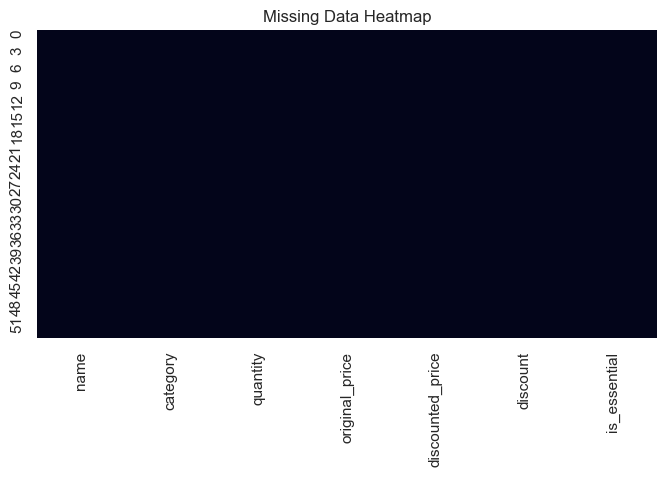

In [5]:
na_counts = df.isna().sum()
na_pct = (na_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": na_counts, "missing_pct": na_pct})

print("Missing summary:")
display(missing_df)

plt.figure(figsize=(8, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

## 5. Compute Descriptive Statistics (Numeric Features)
Convert pricing/discount fields to numeric where needed and compute summary metrics.

In [15]:
if df["discount"].dtype == object:
    df["discount_pct"] = df["discount"].str.rstrip("% ").astype(float)
else:
    df["discount_pct"] = df["discount"].astype(float)

for col in ["original_price", "discounted_price"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["savings"] = df["original_price"] - df["discounted_price"]
df["discount_ratio"] = df["discounted_price"] / df["original_price"]

df["is_essential"] = (
    df["is_essential"].astype(str).str.lower().isin(["true", "1", "yes"])
)

numeric_cols = ["original_price", "discounted_price", "discount_pct", "savings", "discount_ratio"]

print("Numeric summary:")
display(df[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75]).T)

print("\nSkewness:")
display(df[numeric_cols].skew().to_frame("skew"))

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
original_price,54.00,113.43,96.38,25.00,51.25,90.00,147.50,650.00
discounted_price,54.00,97.61,79.77,20.00,42.00,80.00,127.50,520.00
discount_pct,54.00,13.96,3.09,8.00,12.00,13.00,16.00,25.00
savings,54.00,15.81,17.58,5.00,7.00,10.00,20.00,130.00
discount_ratio,54.00,0.86,0.03,0.75,0.84,0.87,0.88,0.92



Skewness:


,skew
original_price,3.46
discounted_price,3.04
discount_pct,1.04
savings,5.35
discount_ratio,-1.16


## 6. Analyze Categorical Distributions
Identify dominant categories and essential vs non-essential split.

In [7]:
cat_counts = df["category"].value_counts().to_frame("count")
cat_counts["pct"] = (cat_counts["count"] / len(df) * 100).round(2)

print("Category distribution:")
display(cat_counts)

essential_counts = df["is_essential"].value_counts().rename_axis("is_essential").to_frame("count")
essential_counts["pct"] = (essential_counts["count"] / len(df) * 100).round(2)

print("\nEssential vs non-essential:")
display(essential_counts)

Category distribution:


,count,pct
category,,
Household,7,12.96
Vegetables,6,11.11
Dairy,5,9.26
Snacks,4,7.41
Spices,4,7.41
Cooking,3,5.56
Pulses,3,5.56
Essentials,3,5.56
Fruits,3,5.56



Essential vs non-essential:


,count,pct
is_essential,,
True,35,64.81
False,19,35.19


## 7. Visualize Numeric Distributions
Inspect spread/outliers for key numeric fields.

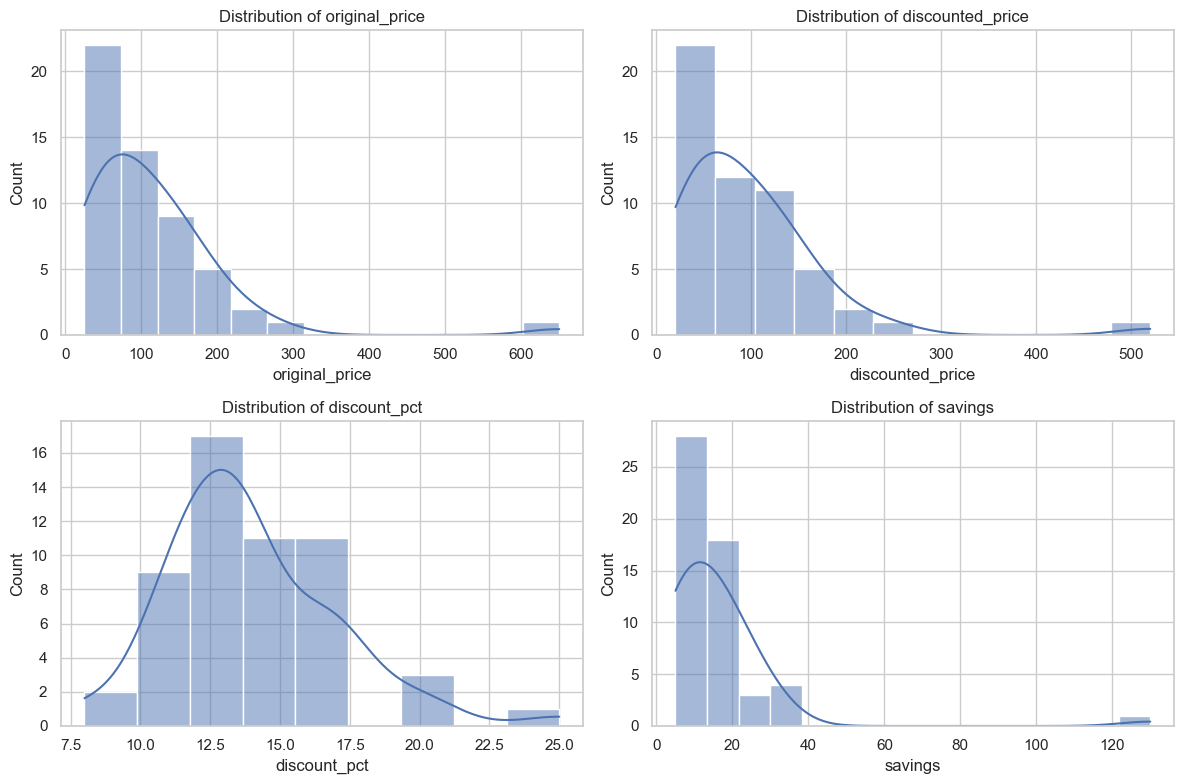

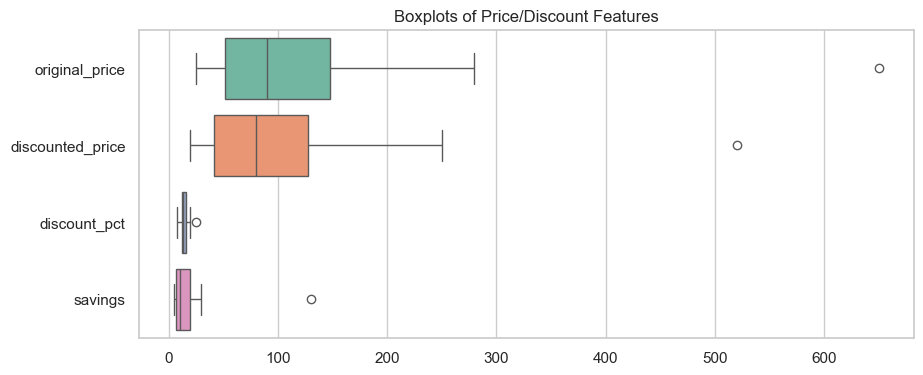

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_cols = ["original_price", "discounted_price", "discount_pct", "savings"]

for ax, col in zip(axes.flat, plot_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color="#4c72b0")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(data=df[plot_cols], orient="h", palette="Set2")
plt.title("Boxplots of Price/Discount Features")
plt.show()

## 8. Correlation Analysis for Numeric Features
Evaluate relationships between pricing and discount measures.

Correlation matrix:


,original_price,discounted_price,discount_pct,savings,discount_ratio
original_price,1.00,1.00,0.02,0.95,-0.02
discounted_price,1.00,1.00,-0.02,0.93,0.02
discount_pct,0.02,-0.02,1.00,0.23,-0.99
savings,0.95,0.93,0.23,1.00,-0.23
discount_ratio,-0.02,0.02,-0.99,-0.23,1.00


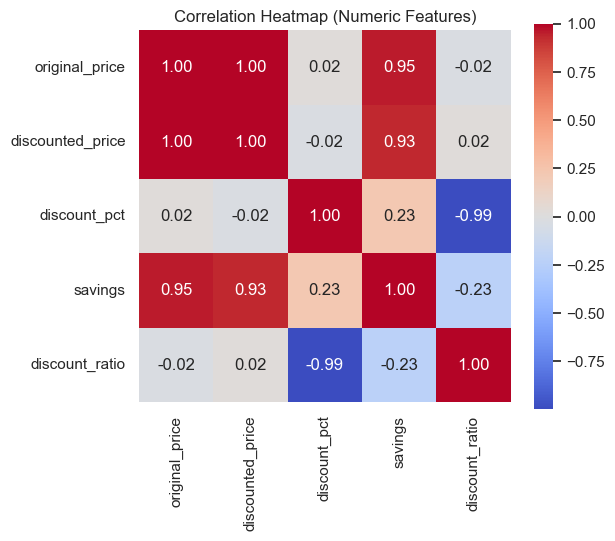

In [9]:
numeric_cols = ["original_price", "discounted_price", "discount_pct", "savings", "discount_ratio"]

corr = df[numeric_cols].corr()
print("Correlation matrix:")
display(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

## 9. Save Cleaned Data or Summary Outputs
Persist cleaned numeric fields for downstream tasks.

## 10. Machine Learning: KNN-Based Substitute Product Recommendation
Implement K-Nearest Neighbors to find cheaper product alternatives in the same category.

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from typing import List, Dict, Optional

class SubstituteRecommender:
    """
    K-Nearest Neighbors recommender for product substitutes.
    Finds cheaper alternatives in the same category based on product features.
    """
    
    def __init__(self, df: pd.DataFrame, k: int = 5):
        """Initialize the recommender with product data."""
        self.df = df.copy()
        self.k = k
        self.scaler = StandardScaler()
        self.model = None
        self.feature_matrix = None
        self._prepare_features()
        self._build_model()
    
    def _prepare_features(self) -> None:
        """Prepare feature matrix for KNN: [price, discount%, is_essential]"""
        self.df['discount_pct'] = (
            (self.df['original_price'] - self.df['discounted_price']) 
            / self.df['original_price'] * 100
        ).fillna(0)
        self.df['is_essential_flag'] = self.df['is_essential'].astype(int)
        
        feature_cols = ['discounted_price', 'discount_pct', 'is_essential_flag']
        self.feature_matrix = self.df[feature_cols].fillna(0).values
        self.feature_matrix_normalized = self.scaler.fit_transform(self.feature_matrix)
    
    def _build_model(self) -> None:
        """Build KNN model on normalized features."""
        self.model = NearestNeighbors(
            n_neighbors=min(self.k + 1, len(self.df)),
            metric='euclidean',
            algorithm='auto'
        )
        self.model.fit(self.feature_matrix_normalized)
    
    def get_substitutes(
        self, 
        product_name: str,
        k_neighbors: Optional[int] = None,
        cheaper_only: bool = True,
        same_category: bool = True
    ) -> List[Dict]:
        """Get substitute recommendations for a product."""
        if k_neighbors is None:
            k_neighbors = self.k
        
        product_mask = self.df['name'].str.lower() == product_name.lower()
        if not product_mask.any():
            return []
        
        product_idx = product_mask.idxmax()
        product_row = self.df.loc[product_idx]
        
        # Get neighbors
        distances, indices = self.model.kneighbors(
            [self.feature_matrix_normalized[product_idx]],
            n_neighbors=k_neighbors + 1
        )
        
        indices = indices[0]
        distances = distances[0]
        mask = indices != product_idx
        indices = indices[mask]
        distances = distances[mask]
        
        # Filter and sort candidates
        candidates = self.df.iloc[indices].copy()
        candidates['knn_distance'] = distances
        candidates['price_difference'] = (
            candidates['discounted_price'] - product_row['discounted_price']
        )
        
        if same_category:
            candidates = candidates[candidates['category'] == product_row['category']]
        
        if cheaper_only:
            candidates = candidates[
                candidates['discounted_price'] < product_row['discounted_price']
            ]
        
        if candidates.empty:
            return []
        
        candidates = candidates.sort_values(
            by=['price_difference', 'knn_distance'],
            ascending=[True, True]
        )
        
        results = []
        for _, row in candidates.head(k_neighbors).iterrows():
            savings = row['original_price'] - row['discounted_price']
            results.append({
                'name': row['name'],
                'category': row['category'],
                'discounted_price': float(row['discounted_price']),
                'original_price': float(row['original_price']),
                'discount_pct': float(row['discount_pct']),
                'savings': float(savings),
                'price_difference': float(row['price_difference']),
                'knn_distance': float(row['knn_distance'])
            })
        
        return results

# Initialize recommender with k=5 neighbors
recommender = SubstituteRecommender(df, k=5)
print(f"✓ KNN Recommender initialized with {len(df)} products and k={recommender.k}")

✓ KNN Recommender initialized with 54 products and k=5


In [10]:
# Uncomment to persist cleaned dataset
# df.to_csv("products_cleaned.csv", index=False)

# Example: export category summary
# (cat_counts.reset_index().rename(columns={"index": "category"})
#  .to_csv("category_summary.csv", index=False))

print("Ready for downstream use; uncomment saves above to export.")

Ready for downstream use; uncomment saves above to export.


In [17]:
# Export recommendations to JSON
export_recommendations = {}

for product_name in df['name'].unique():
    subs = recommender.get_substitutes(product_name, k_neighbors=5)
    
    if subs:
        original_product = df[df['name'] == product_name].iloc[0]
        export_recommendations[product_name] = {
            'category': original_product['category'],
            'current_price': float(original_product['discounted_price']),
            'original_price': float(original_product['original_price']),
            'current_discount': float(original_product['discount_pct']),
            'substitutes': subs,
            'count': len(subs),
            'metadata': {
                'recommendation_method': 'KNN (K-Nearest Neighbors)',
                'k': 5,
                'features': ['discounted_price', 'discount_pct', 'is_essential'],
                'filter_criteria': ['same_category', 'cheaper_only']
            }
        }

# Save to JSON
output_path = "substitutes_recommendations.json"
with open(output_path, 'w') as f:
    json.dump(export_recommendations, f, indent=2)

print(f"✓ Exported {len(export_recommendations)} products with KNN-based recommendations")
print(f"✓ Output saved to: {output_path}")
print(f"\nSample recommendation structure:")
sample_product = list(export_recommendations.keys())[0]
print(f"\nProduct: {sample_product}")
print(json.dumps(export_recommendations[sample_product], indent=2)[:500] + "...")


✓ Exported 15 products with KNN-based recommendations
✓ Output saved to: substitutes_recommendations.json

Sample recommendation structure:

Product: Basmati Rice
{
  "category": "Grains",
  "current_price": 520.0,
  "original_price": 650.0,
  "current_discount": 20.0,
  "substitutes": [
    {
      "name": "Wheat Flour",
      "category": "Grains",
      "discounted_price": 250.0,
      "original_price": 280.0,
      "discount_pct": 10.714285714285714,
      "savings": 30.0,
      "price_difference": -270.0,
      "knn_distance": 4.612985737586548
    }
  ],
  "count": 1,
  "metadata": {
    "recommendation_method": "KNN (K-Nearest Neighbors)",
    "k": ...


### 10.6 Export Recommendations for Application Integration
Save all substitute recommendations to JSON for use in the IntelliGrocer application.

KNN Distance Statistics:
Mean Distance: 0.8038
Median Distance: 0.4611
Std Dev: 0.9791
Min Distance: 0.1812
Max Distance: 4.6130


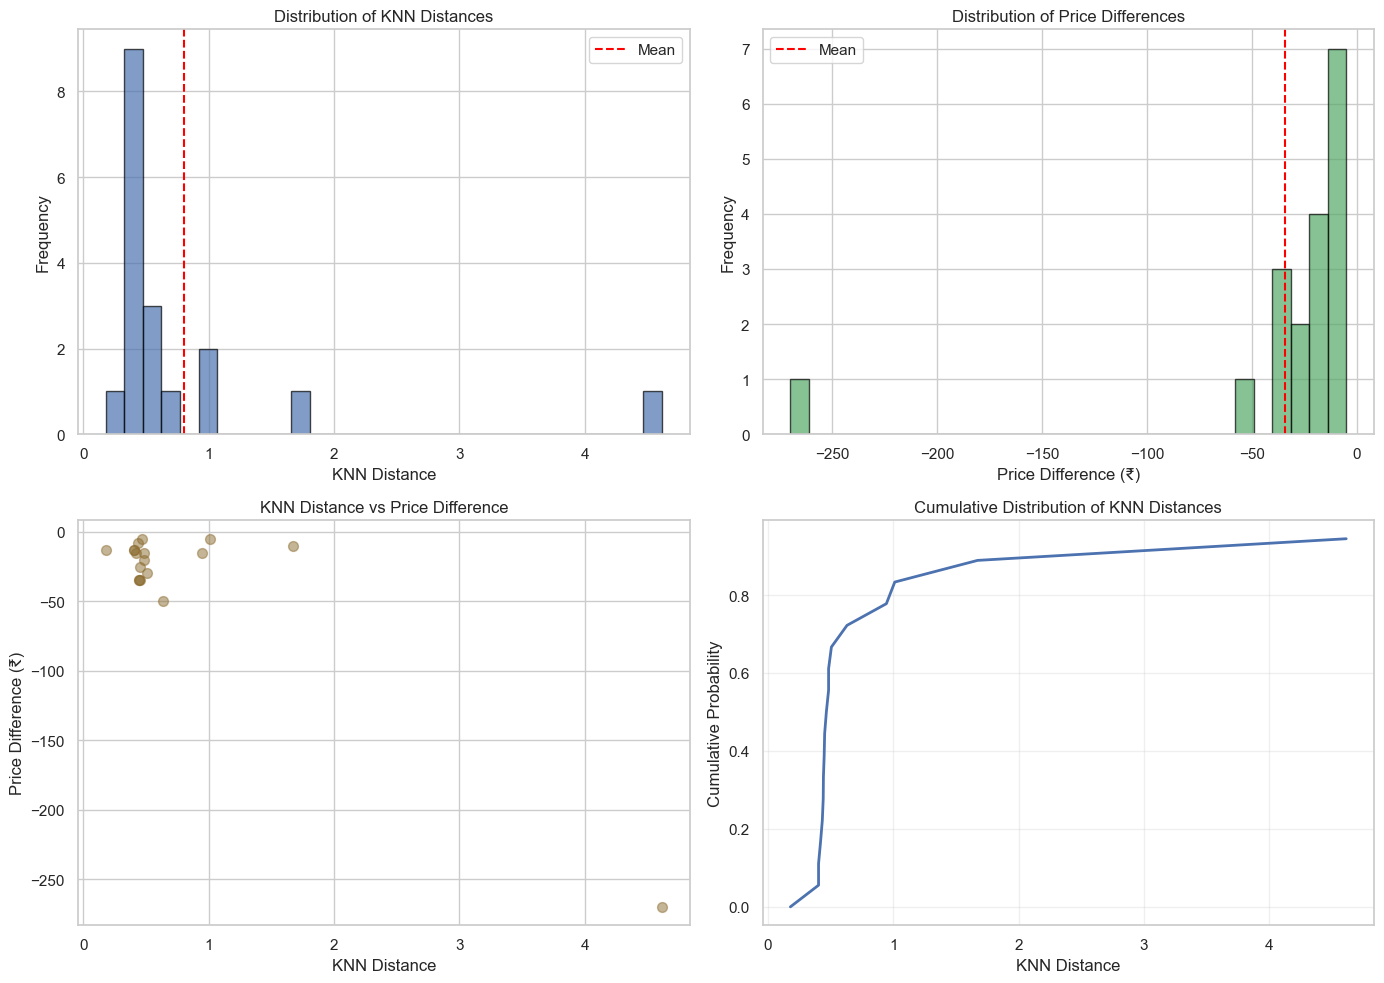

In [18]:
# Collect KNN distances from all recommendations
all_distances = []
all_price_diffs = []

for product_name in df['name'].unique():
    subs = recommender.get_substitutes(product_name, k_neighbors=5)
    for sub in subs:
        all_distances.append(sub['knn_distance'])
        all_price_diffs.append(sub['price_difference'])

print("KNN Distance Statistics:")
print("=" * 60)
print(f"Mean Distance: {np.mean(all_distances):.4f}")
print(f"Median Distance: {np.median(all_distances):.4f}")
print(f"Std Dev: {np.std(all_distances):.4f}")
print(f"Min Distance: {np.min(all_distances):.4f}")
print(f"Max Distance: {np.max(all_distances):.4f}")
print("=" * 60)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# KNN distance distribution
axes[0, 0].hist(all_distances, bins=30, color='#4c72b0', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('KNN Distance')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of KNN Distances')
axes[0, 0].axvline(np.mean(all_distances), color='red', linestyle='--', label='Mean')
axes[0, 0].legend()

# Price difference distribution
axes[0, 1].hist(all_price_diffs, bins=30, color='#55a868', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Price Difference (₹)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Price Differences')
axes[0, 1].axvline(np.mean(all_price_diffs), color='red', linestyle='--', label='Mean')
axes[0, 1].legend()

# Scatter: distance vs price difference
axes[1, 0].scatter(all_distances, all_price_diffs, alpha=0.5, s=50, color='#8c6d31')
axes[1, 0].set_xlabel('KNN Distance')
axes[1, 0].set_ylabel('Price Difference (₹)')
axes[1, 0].set_title('KNN Distance vs Price Difference')

# Cumulative distribution
sorted_distances = np.sort(all_distances)
axes[1, 1].plot(sorted_distances, np.arange(len(sorted_distances)) / len(sorted_distances), 
                linewidth=2, color='#4c72b0')
axes[1, 1].set_xlabel('KNN Distance')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].set_title('Cumulative Distribution of KNN Distances')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 10.5 KNN Distance Distribution & Model Evaluation
Analyze the distribution of KNN distances to understand recommendation quality.

In [ ]:
# Calculate potential savings from substitutes
total_savings = 0
substitute_count = 0
savings_by_category = {}

for product_name in df['name'].unique():
    subs = recommender.get_substitutes(product_name)
    if subs:
        # Take best substitute (first one - cheapest)
        best_sub = subs[0]
        original_product = df[df['name'] == product_name].iloc[0]
        
        saving = original_product['discounted_price'] - best_sub['discounted_price']
        if saving > 0:
            total_savings += saving
            substitute_count += 1
            
            category = original_product['category']
            if category not in savings_by_category:
                savings_by_category[category] = {'total': 0, 'count': 0}
            savings_by_category[category]['total'] += saving
            savings_by_category[category]['count'] += 1

print("Potential Savings Summary:")
print("=" * 60)
print(f"Total Products with Substitutes: {substitute_count}")
print(f"Total Potential Savings: ₹{total_savings:.2f}")
print(f"Average Savings per Substitution: ₹{total_savings/substitute_count:.2f}" if substitute_count > 0 else "N/A")
print("=" * 60)

print("\nSavings by Category:")
savings_df = pd.DataFrame([
    {
        'category': cat,
        'total_savings': data['total'],
        'products_affected': data['count'],
        'avg_saving_per_product': data['total'] / data['count']
    }
    for cat, data in savings_by_category.items()
]).sort_values('total_savings', ascending=False)

display(savings_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

savings_df.sort_values('total_savings', ascending=True).plot(
    x='category', y='total_savings', kind='barh', ax=axes[0], legend=False, color='#c5b0d5'
)
axes[0].set_xlabel('Total Potential Savings (₹)')
axes[0].set_title('Total Savings by Category')
axes[0].set_ylabel('')

savings_df.sort_values('avg_saving_per_product', ascending=True).plot(
    x='category', y='avg_saving_per_product', kind='barh', ax=axes[1], legend=False, color='#c44e52'
)
axes[1].set_xlabel('Average Saving per Product (₹)')
axes[1].set_title('Average Savings per Product by Category')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### 10.4 Savings Potential Analysis
Calculate total potential savings from using substitute recommendations.

In [ ]:
# Analyze substitute availability by category
substitute_availability = {}

for category in df['category'].unique():
    category_products = df[df['category'] == category]['name'].tolist()
    products_with_subs = 0
    total_subs = 0
    
    for product in category_products:
        subs = recommender.get_substitutes(product)
        if subs:
            products_with_subs += 1
            total_subs += len(subs)
    
    substitute_availability[category] = {
        'total_products': len(category_products),
        'products_with_substitutes': products_with_subs,
        'total_substitutes': total_subs,
        'avg_substitutes_per_product': total_subs / len(category_products) if len(category_products) > 0 else 0,
        'coverage': (products_with_subs / len(category_products) * 100) if len(category_products) > 0 else 0
    }

avail_df = pd.DataFrame(substitute_availability).T
avail_df = avail_df.sort_values('coverage', ascending=False)

print("Substitute Availability by Category:")
print("=" * 100)
display(avail_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coverage chart
avail_df['coverage'].sort_values(ascending=True).plot(kind='barh', ax=axes[0], color='#4c72b0')
axes[0].set_xlabel('Coverage %')
axes[0].set_title('Substitute Coverage by Category')
axes[0].set_xlim(0, 100)

# Avg substitutes per product
avail_df['avg_substitutes_per_product'].sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='#55a868'
)
axes[1].set_xlabel('Avg Substitutes per Product')
axes[1].set_title('Average Substitutes per Product by Category')

plt.tight_layout()
plt.show()


### 10.3 Category-Level Analysis: Substitute Availability
Identify which product categories have the most available substitutes.

In [ ]:
# Test with a sample product
test_product = df.iloc[0]['name']
original_product = df[df['name'] == test_product].iloc[0]

print(f"Original Product: {test_product}")
print(f"  Category: {original_product['category']}")
print(f"  Price: ₹{original_product['discounted_price']:.2f}")
print(f"  Discount: {original_product['discount_pct']:.1f}%")
print(f"  Savings: ₹{original_product['savings']:.2f}")
print()

# Get substitutes
substitutes = recommender.get_substitutes(test_product, k_neighbors=5)

if substitutes:
    print(f"Top 5 Cheaper Alternatives for '{test_product}':")
    print("=" * 80)
    
    sub_df = pd.DataFrame(substitutes)
    sub_df['total_savings'] = original_product['discounted_price'] - sub_df['discounted_price']
    
    display_cols = ['name', 'category', 'discounted_price', 'discount_pct', 'total_savings', 'knn_distance']
    display(sub_df[display_cols].to_string(index=False))
else:
    print(f"No cheaper substitutes found for '{test_product}'")


### 10.2 Example: Single Product Substitute Recommendation
Demonstrate KNN-based recommendations for a specific product.

In [ ]:
stats = {
    'Total Products': len(df),
    'Total Categories': df['category'].nunique(),
    'Avg Products/Category': len(df) / df['category'].nunique(),
    'Price Range': f"₹{df['discounted_price'].min():.2f} - ₹{df['discounted_price'].max():.2f}",
    'Avg Price': f"₹{df['discounted_price'].mean():.2f}",
    'Avg Discount': f"{df['discount_pct'].mean():.2f}%"
}

print("KNN Recommendation Engine Statistics:")
print("=" * 50)
for key, value in stats.items():
    print(f"{key:.<30} {value}")
print("=" * 50)

# Feature correlations
feature_cols_analysis = ['discounted_price', 'discount_pct', 'savings']
print("\nFeature Importance (Correlation with Price):")
price_corr = df[feature_cols_analysis].corr()['discounted_price'].sort_values(ascending=False)
display(price_corr)


### 10.1 Engine Statistics & Feature Analysis
Overview of the KNN recommendation engine performance and feature importance.

## 10. Machine Learning: KNN-Based Substitute Product Recommendation
Implement K-Nearest Neighbors to find cheaper product alternatives in the same category.